Install Required Libraries

In [1]:
%matplotlib inline
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

Create the Bell Pair

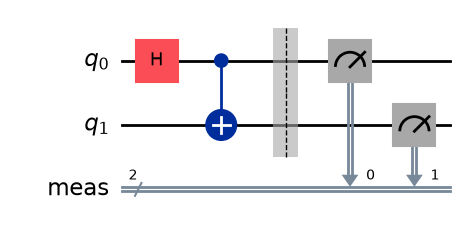

In [2]:
# Create a 2-qubit circuit
qc = QuantumCircuit(2)

# Prepare Bell state: |00⟩ + |11⟩ / √2
qc.h(0)      # Hadamard on qubit 0
qc.cx(0, 1)  # CNOT from qubit 0 to qubit 1

# Measure all qubits
qc.measure_all()

# Display the circuit
fig = qc.draw('mpl')
plt.show()

Run the Circuit on AerSimulator

Measurement counts:
{'11': 505, '00': 519}


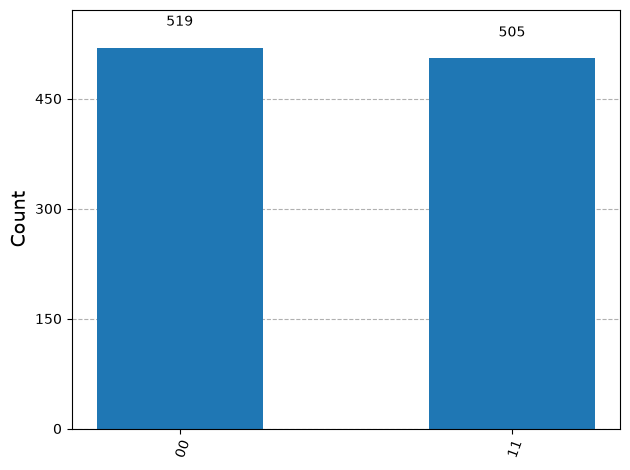

In [3]:
# Initialize simulator
simulator = AerSimulator()

# Transpile the circuit for the simulator
qc_transpiled = transpile(qc, simulator)

# Run with 1024 shots
result = simulator.run(qc_transpiled, shots=1024).result()

# Get measurement counts
counts = result.get_counts()
print("Measurement counts:")
print(counts)

# Display measurement histogram cleanly
fig_hist = plot_histogram(counts)
plt.show()

Prove Correlations Violate Classical Bounds

In [4]:
# Total shots
total_shots = sum(counts.values())

# Expectation value of Z⊗Z
expectation = 0
for state, count in counts.items():
    if state in ['00', '11']:
        expectation += count
    else:
        expectation -= count

expectation_value = expectation / total_shots
print(f"Expectation value <Z⊗Z> = {expectation_value:.4f}")

Expectation value <Z⊗Z> = 1.0000


Full Code

Measurement counts: {'11': 506, '00': 518}


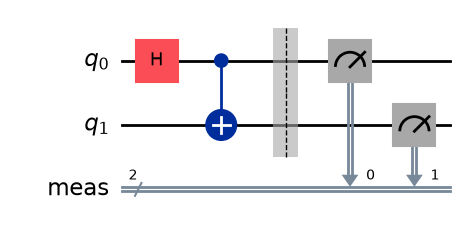

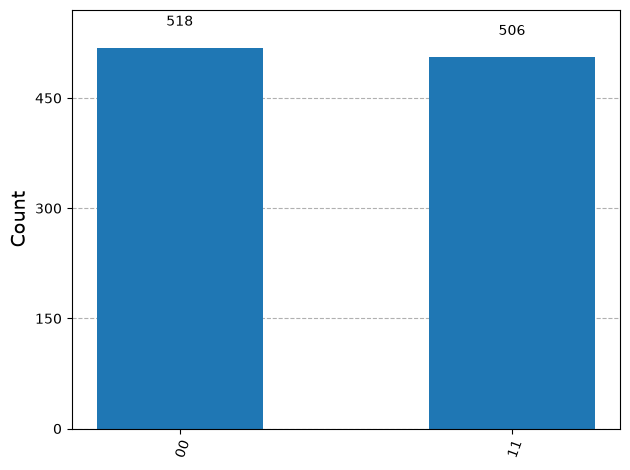

<Z⊗Z> = 1.0000


In [5]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Create Bell pair circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# Draw circuit
fig_circuit = qc.draw('mpl')

# Simulate circuit
simulator = AerSimulator()
qc_transpiled = transpile(qc, simulator)
result = simulator.run(qc_transpiled, shots=1024).result()
counts = result.get_counts()

# Print & plot measurement counts
print("Measurement counts:", counts)
fig_hist = plot_histogram(counts)
plt.show()

# Calculate Expectation value
total = sum(counts.values())
exp_val = sum(count if state in ['00','11'] else -count for state, count in counts.items()) / total
print(f"<Z⊗Z> = {exp_val:.4f}")